In [50]:
import pandas as pd
df = pd.read_csv('../data/raw/tsla_articles.csv')
df.head()

,Unnamed: 0,date,text
0,0,2021-01-27,The company benefited from a jump in sales of ...
1,1,2021-01-19,"Rivian, which has raised another $2.65 billion..."
2,2,2021-01-15,Traditional automakers have struggled to sell ...
3,3,2021-01-22,The pandemic dampened sales for all automakers...
4,4,2021-01-07,Mr. Musk’s net worth was $188.5 billion at 10:...


In [51]:
from transformers import BertForSequenceClassification, AutoTokenizer, pipeline
# Initialize FinTwitBERT sentiment classifier
def initialize_sentiment_analyzer():
    model = BertForSequenceClassification.from_pretrained(
        "StephanAkkerman/FinTwitBERT-sentiment",
        num_labels=3,
        id2label={0: "neutral", 1: "positive", 2: "negative"},
        label2id={"neutral": 0, "positive": 1, "negative": 2},
    )
    tokenizer = AutoTokenizer.from_pretrained("StephanAkkerman/FinTwitBERT-sentiment")
    return pipeline("text-classification", model=model, tokenizer=tokenizer, return_all_scores=True, device=-1)

sentiment_classifier = initialize_sentiment_analyzer()

def classify_net_sentiment(text):
    try:
        scores = sentiment_classifier(text)[0]
        score_dict = {item['label']: item['score'] for item in scores}
        return score_dict.get("positive", 0) - score_dict.get("negative", 0)
    except:
        return None  # or 0 if you prefer

# Apply to your DataFrame
df["net_sentiment"] = df["text"].apply(classify_net_sentiment)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [52]:
daily_sentiment = df.groupby("date").agg({
    "net_sentiment": "mean"
}).reset_index()

In [53]:
daily_sentiment

,date,net_sentiment
0,2020-01-01,0.899516
1,2020-01-03,0.973886
2,2020-01-04,-0.185437
3,2020-01-09,-0.355640
4,2020-01-10,-0.420654
...,...,...
847,2024-06-18,-0.999800
848,2024-06-21,0.208686
849,2024-06-24,-0.997312
850,2024-06-25,-0.199719


In [54]:
import pandas as pd

# Convert 'date' to datetime
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])
daily_sentiment['weekday'] = daily_sentiment['date'].dt.weekday

# Separate Saturday and Sunday
saturdays = daily_sentiment[daily_sentiment['weekday'] == 5]
sundays = daily_sentiment[daily_sentiment['weekday'] == 6]

# Shift Saturdays to Friday, Sundays to Monday
saturdays['date'] = saturdays['date'] - pd.Timedelta(days=1)
sundays['date'] = sundays['date'] + pd.Timedelta(days=1)

# Combine and remove original weekend rows
weekdays = daily_sentiment[daily_sentiment['weekday'] < 5]
adjusted = pd.concat([weekdays, saturdays, sundays])

# Group by date and average net_sentiment
adjusted = adjusted.groupby('date', as_index=False)['net_sentiment'].mean()

# Sort by date
adjusted = adjusted.sort_values('date').reset_index(drop=True)

adjusted

/var/folders/ql/h6gwcsq126l6rhw5rbzqrl0w0000gn/T/ipykernel_83384/3446292412.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saturdays['date'] = saturdays['date'] - pd.Timedelta(days=1)
/var/folders/ql/h6gwcsq126l6rhw5rbzqrl0w0000gn/T/ipykernel_83384/3446292412.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sundays['date'] = sundays['date'] + pd.Timedelta(days=1)


,date,net_sentiment
0,2020-01-01,0.899516
1,2020-01-03,0.394224
2,2020-01-09,-0.355640
3,2020-01-10,-0.420654
4,2020-01-14,0.941123
...,...,...
786,2024-06-18,-0.999800
787,2024-06-21,0.208686
788,2024-06-24,-0.997312
789,2024-06-25,-0.199719


In [55]:
adjusted.to_csv("tsla_sentiment_NoWeekends.csv", index=False)

In [56]:
adjusted

,date,net_sentiment
0,2020-01-01,0.899516
1,2020-01-03,0.394224
2,2020-01-09,-0.355640
3,2020-01-10,-0.420654
4,2020-01-14,0.941123
...,...,...
786,2024-06-18,-0.999800
787,2024-06-21,0.208686
788,2024-06-24,-0.997312
789,2024-06-25,-0.199719


In [57]:
adjusted[adjusted['net_sentiment'] < 0]

,date,net_sentiment
2,2020-01-09,-0.355640
3,2020-01-10,-0.420654
5,2020-01-21,-0.824108
7,2020-01-23,-0.995808
8,2020-01-24,-0.010564
...,...,...
784,2024-06-13,-0.180745
786,2024-06-18,-0.999800
788,2024-06-24,-0.997312
789,2024-06-25,-0.199719


In [58]:
adjusted[adjusted['net_sentiment'] > 0]

,date,net_sentiment
0,2020-01-01,0.899516
1,2020-01-03,0.394224
4,2020-01-14,0.941123
6,2020-01-22,0.000484
11,2020-01-29,0.852821
...,...,...
763,2024-05-06,0.077909
773,2024-05-22,0.950721
775,2024-05-27,0.554603
785,2024-06-14,0.008907


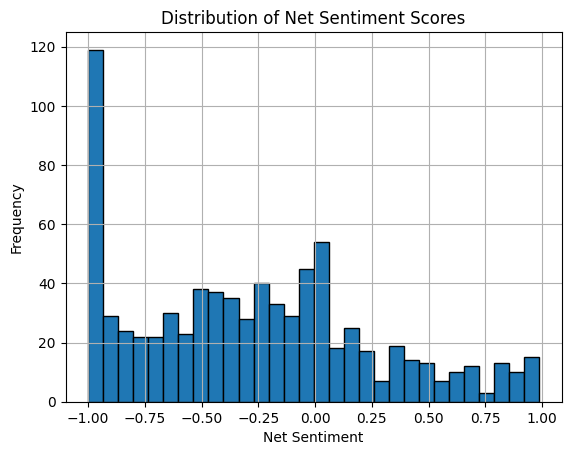

In [59]:
import matplotlib.pyplot as plt

plt.hist(adjusted['net_sentiment'], bins=30, edgecolor='black')
plt.title('Distribution of Net Sentiment Scores')
plt.xlabel('Net Sentiment')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [60]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

RobustScaler = RobustScaler()
StandardScaler = StandardScaler()
adjusted['sentiment_robust_scaled'] = RobustScaler.fit_transform(adjusted[['net_sentiment']])
adjusted['sentiment_standard_scaled'] = StandardScaler.fit_transform(adjusted[['net_sentiment']])

In [61]:
adjusted.head()

,date,net_sentiment,sentiment_robust_scaled,sentiment_standard_scaled
0,2020-01-01,0.899516,1.600845,2.224988
1,2020-01-03,0.394224,0.926320,1.268209
2,2020-01-09,-0.355640,-0.074690,-0.151672
3,2020-01-10,-0.420654,-0.161479,-0.274777
4,2020-01-14,0.941123,1.656387,2.303771


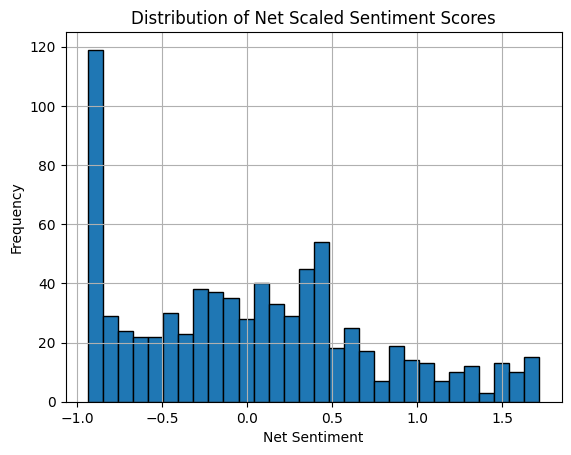

In [62]:
import matplotlib.pyplot as plt

plt.hist(adjusted['sentiment_robust_scaled'], bins=30, edgecolor='black')
plt.title('Distribution of Net Scaled Sentiment Scores')
plt.xlabel('Net Sentiment')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

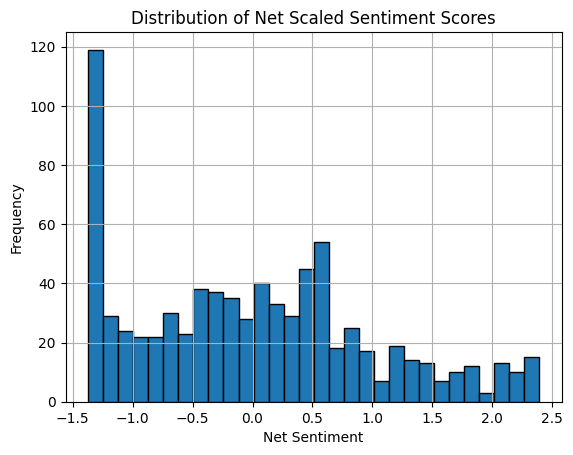

In [63]:
import matplotlib.pyplot as plt

plt.hist(adjusted['sentiment_standard_scaled'], bins=30, edgecolor='black')
plt.title('Distribution of Net Scaled Sentiment Scores')
plt.xlabel('Net Sentiment')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [64]:
adjusted

,date,net_sentiment,sentiment_robust_scaled,sentiment_standard_scaled
0,2020-01-01,0.899516,1.600845,2.224988
1,2020-01-03,0.394224,0.926320,1.268209
2,2020-01-09,-0.355640,-0.074690,-0.151672
3,2020-01-10,-0.420654,-0.161479,-0.274777
4,2020-01-14,0.941123,1.656387,2.303771
...,...,...,...,...
786,2024-06-18,-0.999800,-0.934593,-1.371400
787,2024-06-21,0.208686,0.678641,0.916889
788,2024-06-24,-0.997312,-0.931272,-1.366688
789,2024-06-25,-0.199719,0.133452,0.143567


In [66]:
adjusted.to_csv("../data/tsla_sentiment_NoWeekends_WithScaling.csv", index=False)